시각화에 사용된 데이터 개수: 10642


C:\Users\user\AppData\Local\Temp\ipykernel_29944\1728951651.py:64: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\1728951651.py:64: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\1728951651.py:64: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\1728951651.py:64: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\1728951651.py:64: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\1728951651.py:64: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from fon

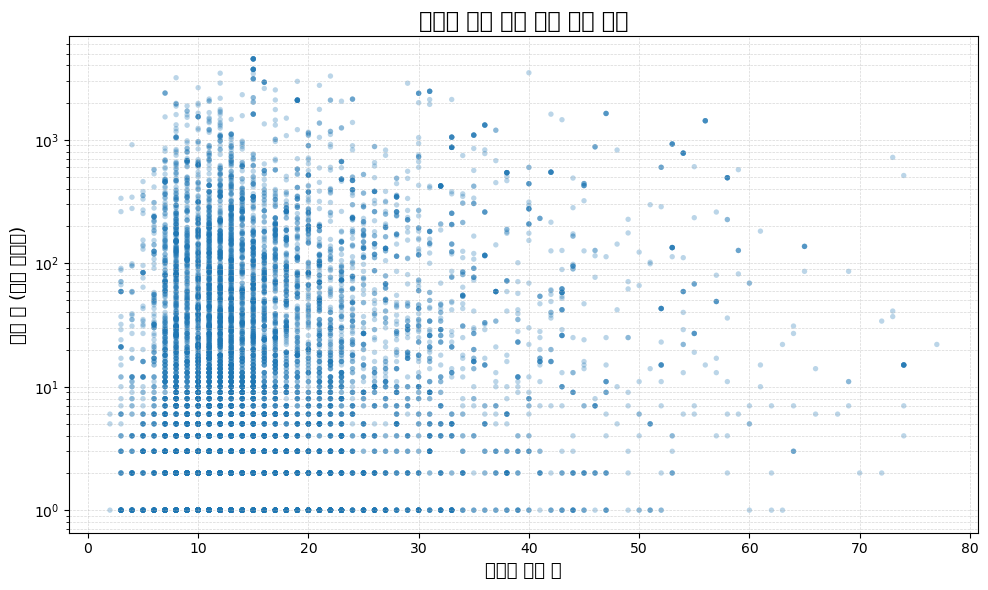

그래프 저장 완료: scatter_titlelen_vs_reviewcount.png


In [3]:
#시술명 글자 수 vs 리뷰 수

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. 데이터 불러오기
# ==========================
df = pd.read_excel("final_treatment_master_preprocessed_for_ml.xlsx")

# 필요한 컬럼만 사용
df_plot = df[["treatment_name_len_char", "review_count"]].copy()

# 결측치 제거
df_plot = df_plot.dropna(subset=["treatment_name_len_char", "review_count"])

# 리뷰 수 0 이하 제거 (로그 스케일을 위해)
df_plot = df_plot[df_plot["review_count"] > 0]

# ==========================
# 2. 이상치 컷 (발표용 시각화 깔끔하게)
#    - 글자 수가 너무 긴 것, 리뷰 수가 비정상적으로 큰 것 잘라내기
# ==========================
# IQR 방식이나 단순 하드컷 중 택 1 (여기선 하드컷으로 간단히)

max_len = 80      # 시술명 글자 수 80자 초과는 잘라냄
max_review = 5000 # 리뷰 수 5000 초과는 잘라냄 (원하는 값으로 조정 가능)

df_plot = df_plot[
    (df_plot["treatment_name_len_char"] <= max_len) &
    (df_plot["review_count"] <= max_review)
]

print("시각화에 사용된 데이터 개수:", len(df_plot))

# ==========================
# 3. 산점도 그리기
# ==========================

plt.figure(figsize=(10, 6))

# 산점도
plt.scatter(
    df_plot["treatment_name_len_char"],
    df_plot["review_count"],
    alpha=0.3,           # 포인트 투명도 (겹침 표현)
    s=15,                # 점 크기
    edgecolors="none"    # 테두리 제거
)

# y축 로그 스케일 (리뷰 수 분포가 치우쳐있어서)
plt.yscale("log")

# ==========================
# 4. 그래프 꾸미기 (발표용)
# ==========================

plt.title("시술명 글자 수와 리뷰 수의 관계", fontsize=16)
plt.xlabel("시술명 글자 수", fontsize=13)
plt.ylabel("리뷰 수 (로그 스케일)", fontsize=13)

plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

# 여백 조정
plt.tight_layout()

# ==========================
# 5. 파일로 저장 (발표자료에 삽입용)
# ==========================
output_path = "scatter_titlelen_vs_reviewcount.png"
plt.savefig(output_path, dpi=300)  # 고해상도 저장
plt.show()

print("그래프 저장 완료:", output_path)

시각화에 사용된 데이터 개수: 10176


C:\Users\user\AppData\Local\Temp\ipykernel_29944\2759610925.py:57: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\2759610925.py:57: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\2759610925.py:57: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\2759610925.py:57: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\2759610925.py:57: UserWarning: Glyph 48624 (\N{HANGUL SYLLABLE BYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\2759610925.py:57: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s)

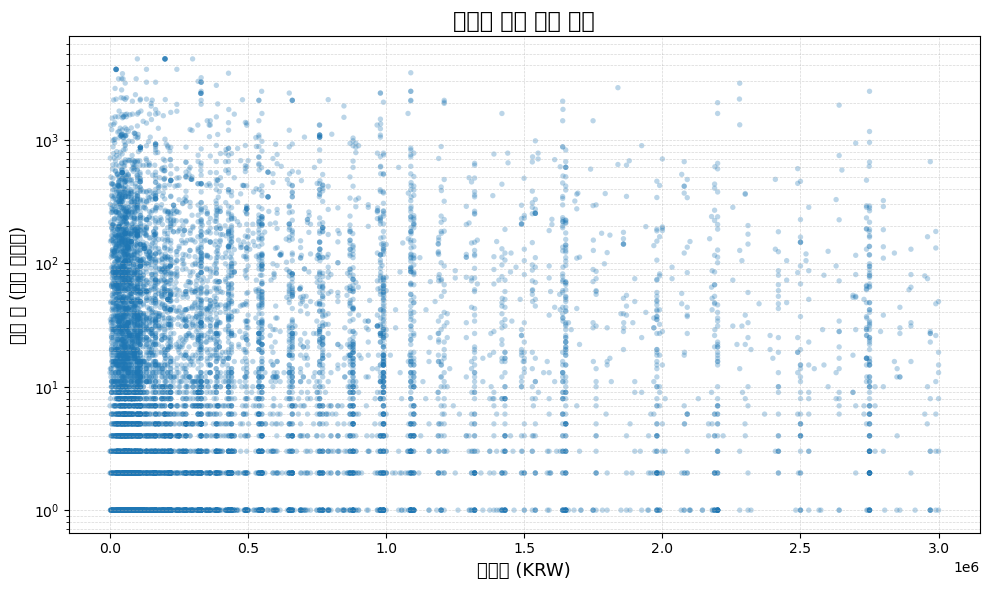

그래프 저장 완료: scatter_price_vs_reviewcount.png


In [4]:
#가격 vs 리뷰 수

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. 데이터 불러오기
# ==========================
df = pd.read_excel("final_treatment_master_preprocessed_for_ml.xlsx")

# 필요한 컬럼만 사용
df_plot = df[["selling_price", "review_count"]].copy()

# 결측치 제거
df_plot = df_plot.dropna(subset=["selling_price", "review_count"])

# 리뷰 0 제거 (로그 스케일을 위해)
df_plot = df_plot[df_plot["review_count"] > 0]

# ==========================
# 2. 이상치 컷 (발표 시각화용)
# ==========================
max_price = 3_000_000   # 300만원 이상은 컷 (필요시 조정)
max_review = 5000       # 리뷰수 5000 이상 컷

df_plot = df_plot[
    (df_plot["selling_price"] <= max_price) &
    (df_plot["review_count"] <= max_review)
]

print("시각화에 사용된 데이터 개수:", len(df_plot))

# ==========================
# 3. 산점도 그리기
# ==========================
plt.figure(figsize=(10, 6))

plt.scatter(
    df_plot["selling_price"],
    df_plot["review_count"],
    alpha=0.3,     # 투명도 (겹침 표시)
    s=15,          # 점 크기
    edgecolors="none"
)

# 리뷰 수 로그 스케일 적용
plt.yscale("log")

# ==========================
# 4. 발표용 스타일링
# ==========================
plt.title("가격과 리뷰 수의 관계", fontsize=16)
plt.xlabel("판매가 (KRW)", fontsize=13)
plt.ylabel("리뷰 수 (로그 스케일)", fontsize=13)

plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()

# ==========================
# 5. 이미지 저장
# ==========================
output_path = "scatter_price_vs_reviewcount.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("그래프 저장 완료:", output_path)

Test R² : 0.728
Test RMSE : 1.0425


C:\Users\user\AppData\Local\Temp\ipykernel_29944\3066364993.py:89: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\3066364993.py:89: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\3066364993.py:89: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\3066364993.py:89: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\3066364993.py:89: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29944\3066364993.py:89: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(

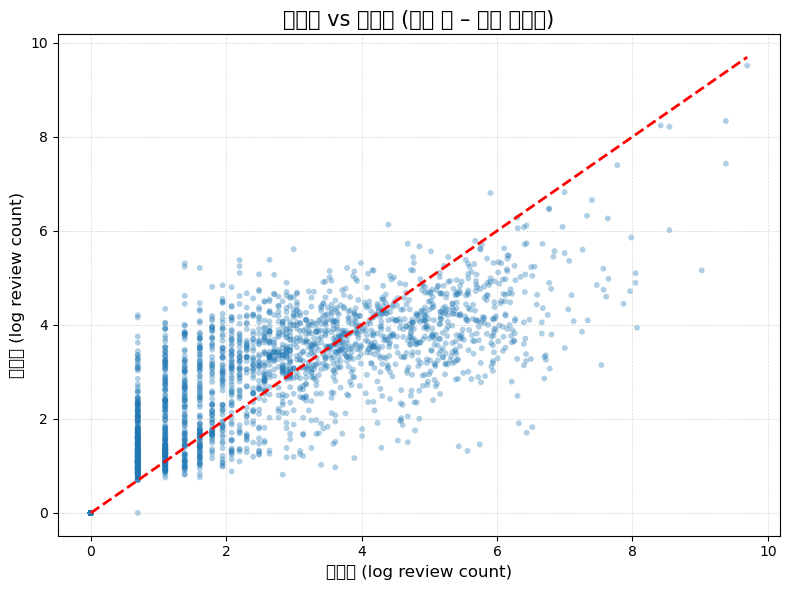

그래프 저장 완료: scatter_pred_vs_actual.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# ==========================
# 1. 데이터 불러오기
# ==========================
df = pd.read_excel("final_treatment_master_preprocessed_for_ml.xlsx")

feature_cols = [
    "platform_id",
    "category_large_id", "category_mid_id", "category_small_id",
    "original_price", "selling_price", "discount_amount", "dis_rate",
    "rating", "rating_per_price",
    "treatment_name_len_char", "treatment_name_len_token",
]

target_col = "log_review_count"

X = df[feature_cols].fillna(0)
y = df[target_col].fillna(0)


# ==========================
# 2. Train/Test 분할 + 스케일링
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


# ==========================
# 3. 모델 학습
# ==========================
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)


# ==========================
# 4. 성능 확인 (참고 출력)
# ==========================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test R² :", round(r2, 4))
print("Test RMSE :", round(rmse, 4))


# ==========================
# 5. 예측값 vs 실제값 산점도 (발표용)
# ==========================
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.35,
    s=18,
    edgecolors="none"
)

# y = x 기준선 (완벽 예측선)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)

plt.title("예측값 vs 실제값 (리뷰 수 – 로그 스케일)", fontsize=15)
plt.xlabel("실제값 (log review count)", fontsize=12)
plt.ylabel("예측값 (log review count)", fontsize=12)

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()

# ==========================
# 6. 이미지 저장
# ==========================
output_path = "scatter_pred_vs_actual.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("그래프 저장 완료:", output_path)